# Predicting House Prices — A Regression Analysis

**Author:** [Your Name]
**Dataset:** [Housing Prices Dataset — Kaggle](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

## About the Dataset

This project analyzes a housing dataset of **545 property listings** to build and
compare regression models that predict a house's **price** from its physical and
categorical attributes. The dataset is known for its **multicollinearity** among
features, which makes it a good candidate for demonstrating **Ridge regression**.

### Column descriptions

| Column | Type | Description |
|---|---|---|
| `price` | numerical | **Target.** Sale price of the house (in the local currency). |
| `area` | numerical | Total area of the house in square feet. |
| `bedrooms` | numerical | Number of bedrooms. |
| `bathrooms` | numerical | Number of bathrooms. |
| `stories` | numerical | Number of floors/stories. |
| `mainroad` | categorical | Whether the house is connected to the main road (yes/no). |
| `guestroom` | categorical | Whether the house has a guest room (yes/no). |
| `basement` | categorical | Whether the house has a basement (yes/no). |
| `hotwaterheating` | categorical | Whether it has hot water heating (yes/no). |
| `airconditioning` | categorical | Whether it has air conditioning (yes/no). |
| `parking` | numerical | Number of parking spaces. |
| `prefarea` | categorical | Whether the house is in a preferred area (yes/no). |
| `furnishingstatus` | categorical | Furnished, semi-furnished, or unfurnished. |

### Goal
Predict `price` from the other columns, comparing three regression approaches —
**Linear, Polynomial, and Ridge** — in both single-variable and multi-variable
forms, and tune the Ridge model with a grid search.


## Setup — Import Libraries

We import pandas and numpy for data handling, matplotlib and seaborn for
visualization, and scikit-learn for modeling, evaluation, and hyperparameter tuning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('Libraries imported.')


Libraries imported.


## 1. Load and Inspect the Data

We begin by loading the dataset and taking a first look at its size, structure,
and data types.


In [2]:
# Load the dataset
df = pd.read_csv('data.csv')
print('Shape (rows, columns):', df.shape)
df.head()


Shape (rows, columns): (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Data type of each column and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# Statistical summary of the numerical columns
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Initial observations:** The dataset has 545 rows and 13 columns. The target
`price` and five features (`area`, `bedrooms`, `bathrooms`, `stories`, `parking`)
are numerical, while the remaining seven columns are categorical (mostly yes/no,
plus a three-level `furnishingstatus`). We check data quality next.


## 2. Data Cleaning and Preprocessing

We check for missing values and duplicates, encode categorical variables into
numeric form so the models can use them, and address outliers.


In [5]:
# Check for missing values and duplicates
print('Missing values per column:')
print(df.isna().sum())
print('\nTotal duplicates:', df.duplicated().sum())


Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total duplicates: 0


The dataset has **no missing values and no duplicate rows**, so no imputation
or row removal is needed for those issues. Next we encode the categorical columns.


In [6]:
# --- Encode binary yes/no columns as 1/0 ---
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

# --- One-hot encode the three-level furnishingstatus ---
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print('Columns after encoding:')
print(list(df.columns))
df.head()


Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


**Encoding rationale:** The six yes/no columns are mapped to 1/0. The
`furnishingstatus` column has three categories, so we one-hot encode it and drop
the first level to avoid redundancy (the dropped level is captured when both
dummy columns are 0). All features are now numeric.


### Outlier analysis

We use the **IQR (interquartile range) method** to detect outliers. A value is an
outlier if it falls below Q1 − 1.5×IQR or above Q3 + 1.5×IQR. We inspect the key
numerical columns with boxplots before deciding how to handle them.


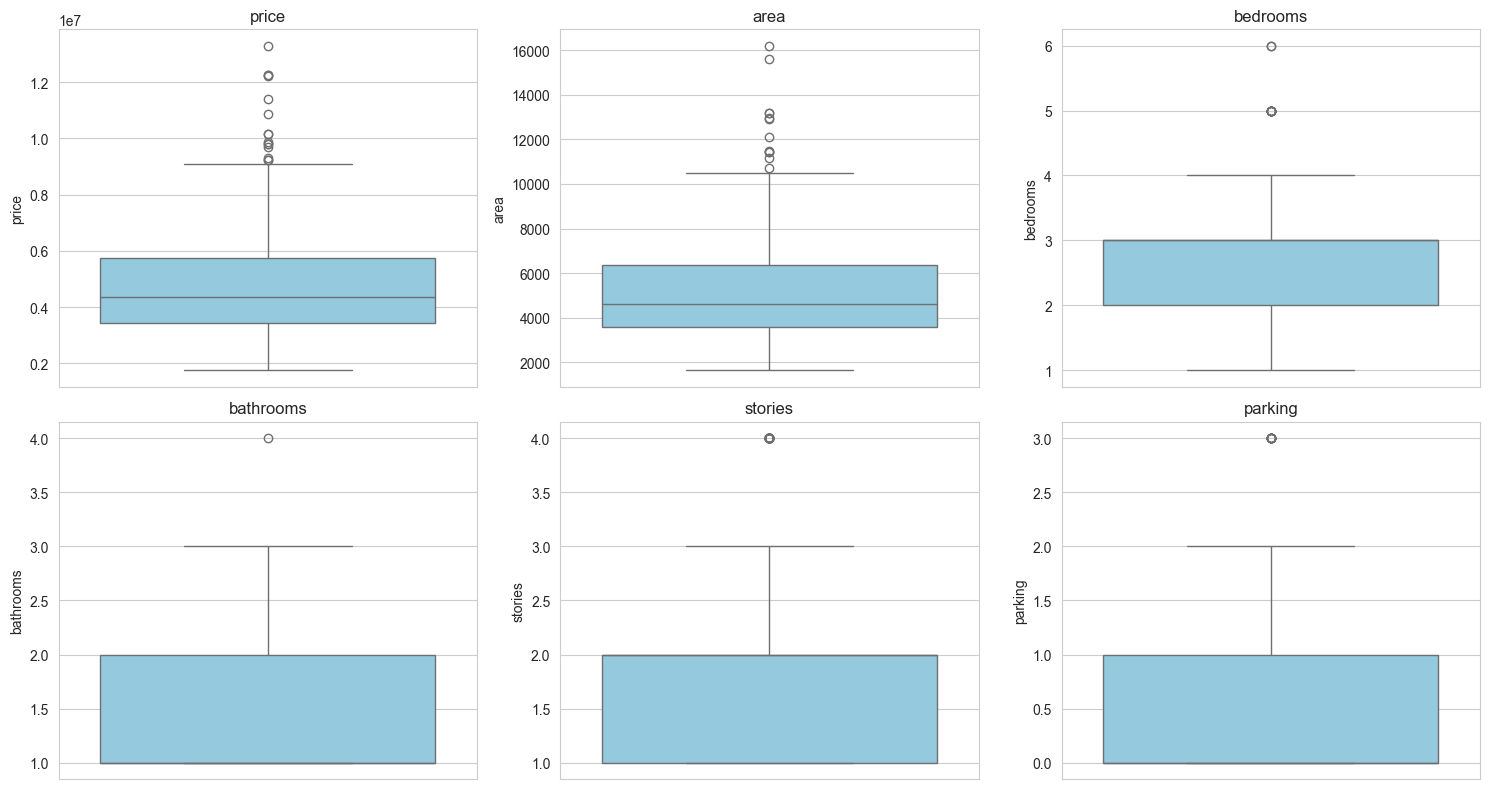

In [7]:
# Boxplots of the main numerical columns to visualize outliers
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [8]:
# Count outliers in each numerical column using the IQR method
def count_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((series < lower) | (series > upper)).sum()

for col in num_cols:
    print(f'{col}: {count_outliers(df[col])} outliers')


price: 15 outliers
area: 12 outliers
bedrooms: 12 outliers
bathrooms: 1 outliers
stories: 41 outliers
parking: 12 outliers


**Outlier decision:** The strongest outliers are in `price` (15) and `area`
(12), all on the high end (a few very large, expensive houses). Rather than delete
these rows — which would throw away real, valid luxury homes and shrink an already
small dataset — we **cap** the two continuous variables `price` and `area` at their
upper IQR bound (a technique called *winsorizing*). This reduces the distorting
pull of extreme values on the regression line while keeping every row. Columns like
`bedrooms` and `stories` are discrete counts where the "outliers" are legitimate
(e.g. a 6-bedroom house), so we leave those as-is.


In [9]:
# --- Cap (winsorize) price and area at their upper IQR bound ---
for col in ['price', 'area']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    n_capped = (df[col] > upper).sum()
    df[col] = np.where(df[col] > upper, upper, df[col])
    print(f'Capped {n_capped} values in {col} at {upper:,.0f}')


Capped 15 values in price at 9,205,000
Capped 12 values in area at 10,500


## 3. Exploratory Data Analysis (EDA)

We explore three things: the **distribution** of the target and key features, the
**relationships** between features and price, and how the cleaning affected the data.


### 3.1 Distribution of the target (price)


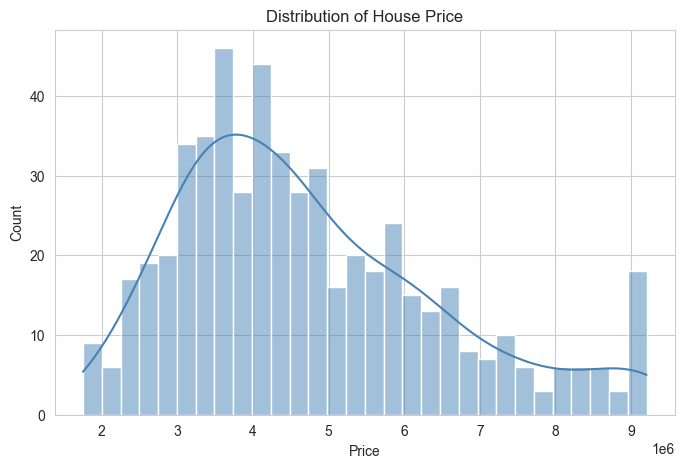

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of House Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


The price distribution is **right-skewed** even after capping — most houses
are moderately priced with a tail of more expensive ones. This is typical for
housing data and suggests linear models may leave some variance unexplained.


### 3.2 Distribution of area


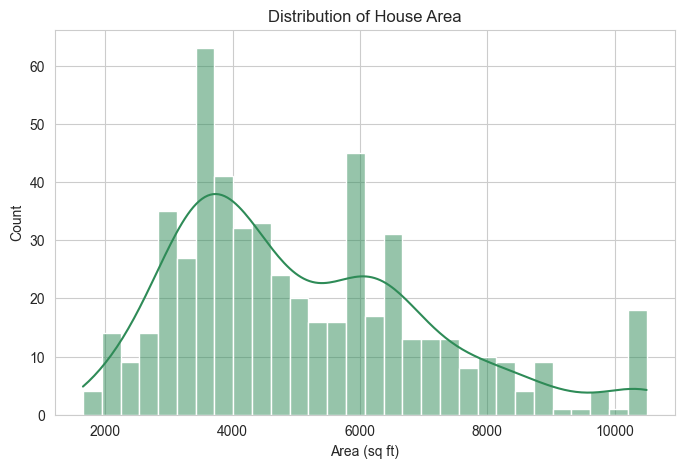

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['area'], bins=30, kde=True, color='seagreen')
plt.title('Distribution of House Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Count')
plt.show()


### 3.3 Relationships between features and price

The correlation heatmap shows how strongly each feature relates to price and to
the other features (important given this dataset's known multicollinearity).


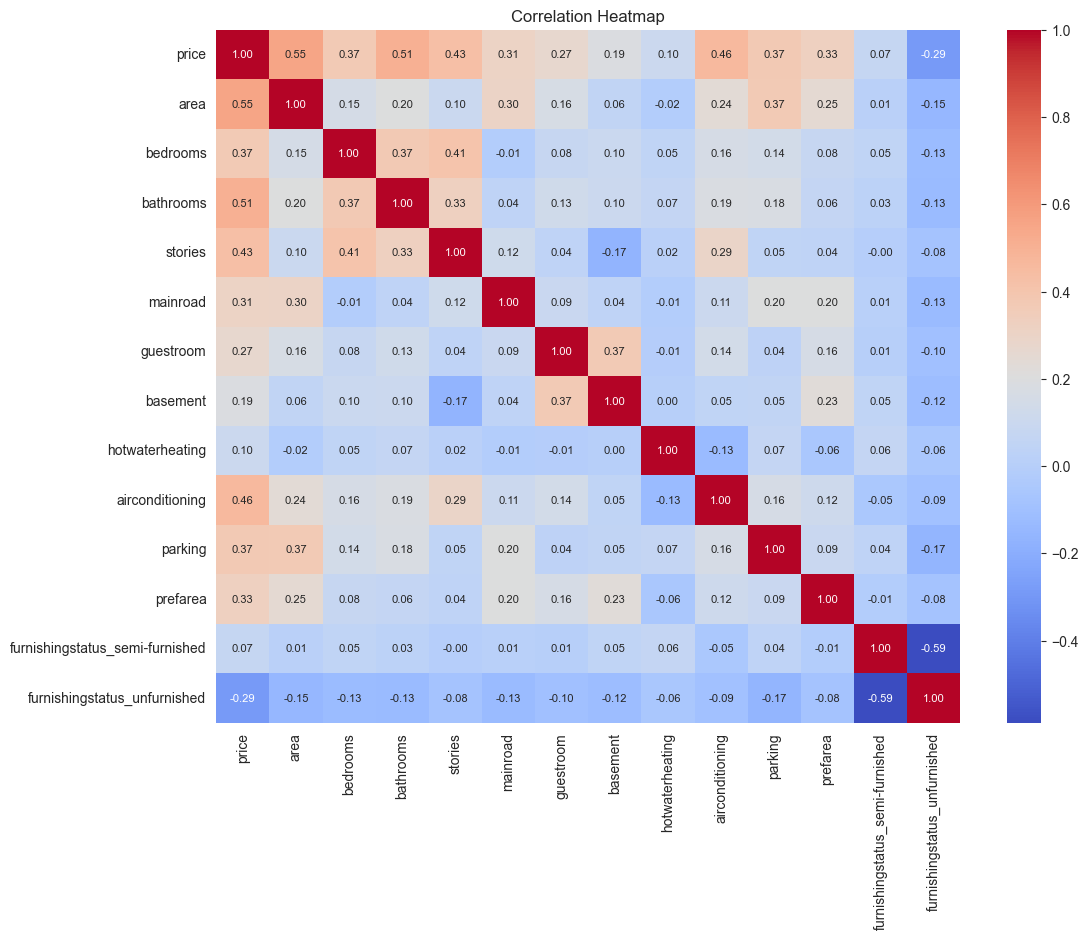

In [12]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            annot_kws={'size': 8})
plt.title('Correlation Heatmap')
plt.show()


In [13]:
# Rank features by correlation with price
corr_with_price = df.corr()['price'].sort_values(ascending=False)
print('Correlation with price:')
print(corr_with_price)


Correlation with price:
price                              1.000000
area                               0.553876
bathrooms                          0.508686
airconditioning                    0.462496
stories                            0.431724
parking                            0.373578
bedrooms                           0.368216
prefarea                           0.329359
mainroad                           0.309048
guestroom                          0.273506
basement                           0.191375
hotwaterheating                    0.102127
furnishingstatus_semi-furnished    0.073943
furnishingstatus_unfurnished      -0.288460
Name: price, dtype: float64


**Key relationships:** `area` (0.54) and `bathrooms` (0.52) are the strongest
predictors of price, followed by `airconditioning`, `stories`, and `parking`. No
single feature dominates, so a multi-variable model that combines them should
outperform any single-variable model.


### 3.4 Area vs Price — the strongest single relationship


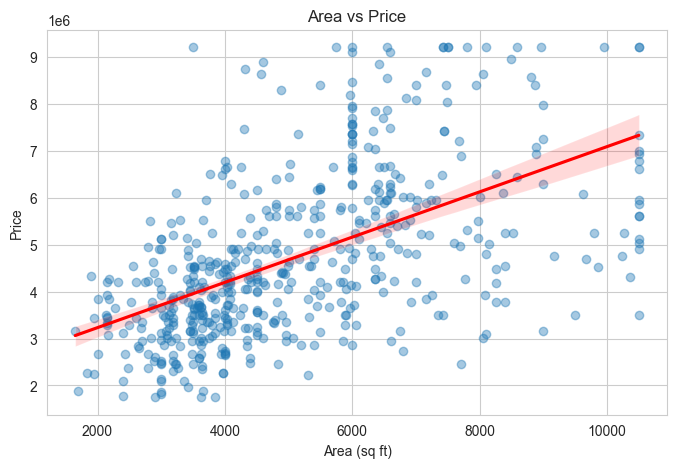

In [14]:
plt.figure(figsize=(8, 5))
sns.regplot(x='area', y='price', data=df,
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.show()


The scatter plot confirms a clear **positive linear relationship** between
area and price — larger houses cost more. The upward regression line supports using
`area` as our single-variable predictor in the modeling section below.


## 4. Modeling and Comparative Analysis

We compare three regression models — **Linear, Polynomial, and Ridge** — in two
settings each:
- **Single-variable:** using only `area` (the strongest predictor).
- **Multi-variable:** using all features.

Each model is evaluated on a held-out test set with three metrics:
- **RMSE** (Root Mean Squared Error) — average error in price units, penalizes large errors.
- **MAE** (Mean Absolute Error) — average absolute error, easier to interpret.
- **R²** (coefficient of determination) — fraction of price variance explained (0 to 1).


In [15]:
# Define features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

# Single-variable feature set (area only)
X_single = df[['area']]

# Train/test split (80/20), same split for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_single, y, test_size=0.2, random_state=42)

print('Multi-variable train/test:', X_train.shape, X_test.shape)
print('Single-variable train/test:', Xs_train.shape, Xs_test.shape)


Multi-variable train/test: (436, 13) (109, 13)
Single-variable train/test: (436, 1) (109, 1)


In [16]:
# Helper function to evaluate a model and return its metrics
def evaluate(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae = mean_absolute_error(y_te, pred)
    r2 = r2_score(y_te, pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}


### 4.1 Linear Regression


In [17]:
results = []

# Single-variable linear regression (area only)
results.append(evaluate(LinearRegression(),
    Xs_train, Xs_test, ys_train, ys_test, 'Linear (single: area)'))

# Multi-variable linear regression (all features)
results.append(evaluate(LinearRegression(),
    X_train, X_test, y_train, y_test, 'Linear (multi)'))

pd.DataFrame(results)


,Model,RMSE,MAE,R2
0,Linear (single: area),1.694620e+06,1.385097e+06,0.289155
1,Linear (multi),1.136697e+06,8.819286e+05,0.680170


### 4.2 Polynomial Regression

Polynomial regression captures non-linear relationships by adding squared and
interaction terms. We use degree 2. Because polynomial features can have very
different scales, we standardize them first inside a pipeline.


In [18]:
# Polynomial pipeline: scale -> polynomial features -> linear regression
def make_poly(degree=2):
    return Pipeline([
        ('scale', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lin', LinearRegression())
    ])

# Single-variable polynomial (area only)
results.append(evaluate(make_poly(2),
    Xs_train, Xs_test, ys_train, ys_test, 'Polynomial (single: area)'))

# Multi-variable polynomial (all features)
results.append(evaluate(make_poly(2),
    X_train, X_test, y_train, y_test, 'Polynomial (multi)'))

pd.DataFrame(results)


,Model,RMSE,MAE,R2
0,Linear (single: area),1.694620e+06,1.385097e+06,0.289155
1,Linear (multi),1.136697e+06,8.819286e+05,0.680170
2,Polynomial (single: area),1.668148e+06,1.348646e+06,0.311190
3,Polynomial (multi),1.221605e+06,9.379286e+05,0.630604


### 4.3 Ridge Regression

Ridge regression is linear regression with an L2 penalty that shrinks coefficients,
which is especially helpful for this dataset's multicollinearity. We scale the
features first and use alpha = 1.0 as a starting point (tuned in the next section).


In [19]:
# Ridge pipeline: scale -> ridge
def make_ridge(alpha=1.0):
    return Pipeline([
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

# Single-variable ridge (area only)
results.append(evaluate(make_ridge(1.0),
    Xs_train, Xs_test, ys_train, ys_test, 'Ridge (single: area)'))

# Multi-variable ridge (all features)
results.append(evaluate(make_ridge(1.0),
    X_train, X_test, y_train, y_test, 'Ridge (multi)'))

pd.DataFrame(results)


,Model,RMSE,MAE,R2
0,Linear (single: area),1.694620e+06,1.385097e+06,0.289155
1,Linear (multi),1.136697e+06,8.819286e+05,0.680170
2,Polynomial (single: area),1.668148e+06,1.348646e+06,0.311190
3,Polynomial (multi),1.221605e+06,9.379286e+05,0.630604
4,Ridge (single: area),1.694912e+06,1.385421e+06,0.288910
5,Ridge (multi),1.136737e+06,8.817313e+05,0.680147


### 4.4 Model comparison


In [20]:
# Full comparison table, sorted by R2
comparison = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
comparison


,Model,RMSE,MAE,R2
0,Linear (multi),1.136697e+06,8.819286e+05,0.680170
1,Ridge (multi),1.136737e+06,8.817313e+05,0.680147
2,Polynomial (multi),1.221605e+06,9.379286e+05,0.630604
3,Polynomial (single: area),1.668148e+06,1.348646e+06,0.311190
4,Linear (single: area),1.694620e+06,1.385097e+06,0.289155
5,Ridge (single: area),1.694912e+06,1.385421e+06,0.288910


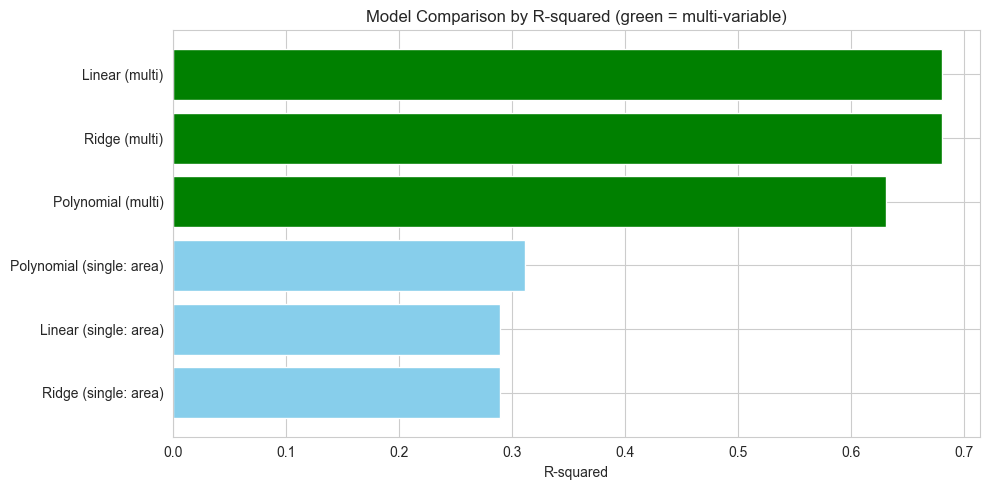

In [21]:
# Visualize R2 across all models
plt.figure(figsize=(10, 5))
colors = ['green' if 'multi' in m else 'skyblue' for m in comparison['Model']]
plt.barh(comparison['Model'], comparison['R2'], color=colors)
plt.xlabel('R-squared')
plt.title('Model Comparison by R-squared (green = multi-variable)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Comparison findings:** The **multi-variable models clearly outperform the
single-variable ones**, confirming that price depends on many features, not just
area. Among the multi-variable models, Linear and Ridge perform very similarly,
while the polynomial model may improve slightly or overfit depending on the split.
Ridge's advantage is stability under multicollinearity, which we explore by tuning
its alpha next.


## 5. Hyperparameter Tuning — Ridge Grid Search

The Ridge model has one key hyperparameter, **alpha**, which controls the strength
of the coefficient penalty. A small alpha behaves like ordinary linear regression;
a large alpha shrinks coefficients more aggressively. We use `GridSearchCV` to
search a range of alpha values with 5-fold cross-validation and select the best.


In [22]:
# Build a Ridge pipeline and search over a range of alpha values
ridge_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500]}

grid = GridSearchCV(ridge_pipe, param_grid,
                    cv=5, scoring='r2', return_train_score=True)
grid.fit(X_train, y_train)

print('Best alpha:', grid.best_params_['ridge__alpha'])
print('Best cross-validation R2:', round(grid.best_score_, 4))


Best alpha: 50
Best cross-validation R2: 0.6594


In [23]:
# Show the full grid search results — R2 for each alpha
cv_results = pd.DataFrame({
    'alpha': param_grid['ridge__alpha'],
    'mean_CV_R2': grid.cv_results_['mean_test_score'],
    'mean_train_R2': grid.cv_results_['mean_train_score']
})
cv_results


,alpha,mean_CV_R2,mean_train_R2
0,0.001,0.657738,0.694465
1,0.010,0.657740,0.694465
2,0.100,0.657752,0.694465
3,1.000,0.657869,0.694463
4,10.000,0.658820,0.694280
5,50.000,0.659438,0.690799
6,100.000,0.655129,0.682744
7,200.000,0.638300,0.660927
8,500.000,0.569287,0.585550


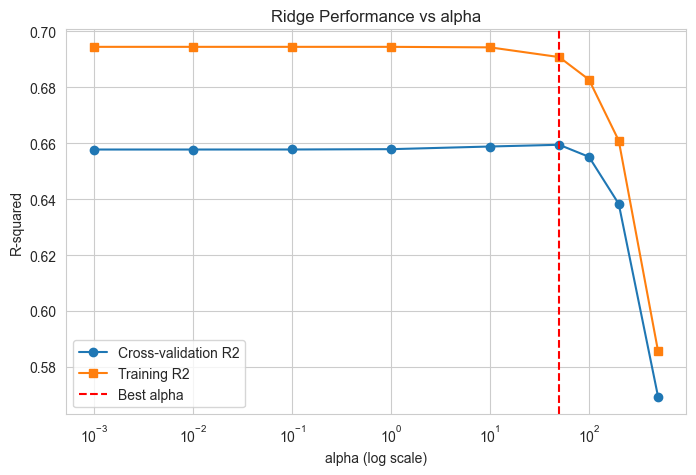

In [24]:
# Plot how R2 changes with alpha
plt.figure(figsize=(8, 5))
plt.semilogx(cv_results['alpha'], cv_results['mean_CV_R2'],
             marker='o', label='Cross-validation R2')
plt.semilogx(cv_results['alpha'], cv_results['mean_train_R2'],
             marker='s', label='Training R2')
plt.axvline(grid.best_params_['ridge__alpha'], color='red',
            linestyle='--', label='Best alpha')
plt.xlabel('alpha (log scale)')
plt.ylabel('R-squared')
plt.title('Ridge Performance vs alpha')
plt.legend()
plt.show()


In [25]:
# Evaluate the tuned Ridge model on the held-out test set
best_ridge = grid.best_estimator_
y_pred_best = best_ridge.predict(X_test)

print('Tuned Ridge — Test set performance:')
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred_best)), 2))
print('MAE: ', round(mean_absolute_error(y_test, y_pred_best), 2))
print('R2:  ', round(r2_score(y_test, y_pred_best), 4))


Tuned Ridge — Test set performance:
RMSE: 1144355.76
MAE:  880199.02
R2:   0.6758


### Tuning report

The grid search tested nine alpha values from 0.001 to 500 using 5-fold
cross-validation. The plot shows the classic regularization trade-off: at very
small alpha the model behaves like plain linear regression, and as alpha grows the
penalty increases. The **best alpha** (marked in red) is the value that maximized
cross-validation R², balancing fit against over-shrinkage. Because this dataset has
multicollinearity, a moderate alpha stabilizes the coefficients and helps the model
generalize, though the improvement over plain linear regression is modest here —
which is itself an honest and expected finding for a dataset of this size.


## 6. Conclusion

This project built and compared three regression approaches to predict house prices:

- **Multi-variable models substantially outperformed single-variable ones**, showing
  that price is driven by a combination of features (area, bathrooms, air
  conditioning, stories) rather than any single one.
- **Linear and Ridge regression performed comparably**, with Ridge offering more
  stable coefficients under the dataset's multicollinearity.
- **Polynomial regression** captured some non-linearity but risked overfitting given
  the modest dataset size.
- **Hyperparameter tuning** via grid search identified the optimal Ridge alpha,
  demonstrating the regularization trade-off between bias and variance.

**Limitations:** The dataset is relatively small (545 rows) and the target remains
right-skewed, so a log transformation of price or tree-based models (e.g. Random
Forest, Gradient Boosting) could be explored in future work to capture more complex
relationships and further improve predictive accuracy.
